# Réactivité rapide avec les interruptions matérielles

## Principe des interruptions

Une interruption est un événement qui survient au processeur, lui forçant d'interrompre immédiatement ce qu'il fait dans le but d'exécuter une tâche plus urgente appelée **ISR** (*Interrupt Service Routine*) ou *Handler*. Ceci garantit une réactivité rapide et efficace. Une fois l'ISR terminée, le processeur reprend exactement là où il s'était arrêté.

**Pourquoi les utiliser ?**

Contrairement au "*polling*" (scrutation) qui consiste à vérifier en boucle l'état d'un bouton, consomme 100% des ressources CPU pour surveiller une broche; l'interruption garantit une réactivité immédiate d'ordre de quelques microsecondes à un événement externe et libère ainsi du temps CPU pour d'autres calculs. **C'est la base du système déterminisme temps réel.**

Sur le STM32F4 toutes les 16 broches de n'importe quel port GPIO peuvent être configurées comme sources d'interruptions externes, grâce au contrôleur `EXTI` (*External Interrupt/Event Controller*). 



## Configuration des interruptions materielles



Pour configurer ce mécanisme, nous utilisons des registres spécifiques :

- Sélection du front (`EXTI_RTSR` et `EXTI_FTSR`) : Le registre `EXTI_RTSR` configure la détection sur front montant, et `EXTI_FTSR` sur front descendant (on peut activer les deux tout depend de l'application).
- Masque individuel (`EXTI_IMR`) : Mettre un bit à `1` autorise matériellement l'interruption sur la ligne `EXTI` correspondante.
- Gestion globale et priorités (Le `NVIC`) : Sur ARM Cortex-M, le contrôle global est confié au `NVIC` (*Nested Vectored Interrupt Controller*). On y active chaque ligne d'interruption et on lui attribue un niveau de priorité (de 0 à 15) via les fonctions CMSIS standardisées :

```c
NVIC_SetPriority(EXTI0_IRQn, 1); // Définit la priorité
NVIC_EnableIRQ(EXTI0_IRQn);      // Autorise l'interruption
```

Pour couper ou réactiver absolument toutes les interruptions configurables du CPU, on utilise les instructions intrinsèques `__disable_irq();` et `__enable_irq();`.

- Le multiplexage (`SYSCFG_EXTICR`) : Comme les broches de même numéro partagent la même ligne d'interruption (PA0, PB0, PC0 partagent la ligne `EXTI0`), ces registres permettent de sélectionner précisément quel port GPIO est connecté à la ligne EXTI.


| Registre CMSIS | Bits | Nom du Bloc | Lignes GPIO associées | Valeur à écrire (Configuration du Port) |
| :--- | :--- | :--- | :--- | :--- |
| **SYSCFG->EXTICR[0]**<br>*(EXTICR1)* | [15:12]<br>[11:8]<br>[7:4]<br>[3:0] | EXTI3<br>EXTI2<br>EXTI1<br>EXTI0 | PA3, PB3, PC3, PD3, PE3, PH3<br>PA2, PB2, PC2, PD2, PE2, PH2<br>PA1, PB1, PC1, PD1, PE1, PH1<br>PA0, PB0, PC0, PD0, PE0, PH0 | **0000 (0x0)** = Port A<br>**0001 (0x1)** = Port B<br>**0010 (0x2)** = Port C<br>**0011 (0x3)** = Port D<br>**0100 (0x4)** = Port E<br><br>**0111 (0x7)** = Port H |
| **SYSCFG->EXTICR[1]**<br>*(EXTICR2)* | [15:12]<br>[11:8]<br>[7:4]<br>[3:0] | EXTI7<br>EXTI6<br>EXTI5<br>EXTI4 | PA7, PB7, PC7, PD7, PE7, PH7<br>PA6, PB6, PC6, PD6, PE6, PH6<br>PA5, PB5, PC5, PD5, PE5, PH5<br>PA4, PB4, PC4, PD4, PE4, PH4 | *Mêmes valeurs :*<br>0x0 = Port A<br>0x1 = Port B<br>0x2 = Port C<br>0x3 = Port D<br>0x4 = Port E<br>0x7 = Port H |
| **SYSCFG->EXTICR[2]**<br>*(EXTICR3)* | [15:12]<br>[11:8]<br>[7:4]<br>[3:0] | EXTI11<br>EXTI10<br>EXTI9<br>EXTI8 | PA11, PB11, PC11, PD11, PE11, PH11<br>PA10, PB10, PC10, PD10, PE10, PH10<br>PA9, PB9, PC9, PD9, PE9, PH9<br>PA8, PB8, PC8, PD8, PE8, PH8 | *Mêmes valeurs :*<br>0x0 = Port A<br>0x1 = Port B<br>0x2 = Port C<br>0x3 = Port D<br>0x4 = Port E<br>0x7 = Port H |
| **SYSCFG->EXTICR[3]**<br>*(EXTICR4)* | [15:12]<br>[11:8]<br>[7:4]<br>[3:0] | EXTI15<br>EXTI14<br>EXTI13<br>EXTI12 | PA15, PB15, PC15, PD15, PE15, PH15<br>PA14, PB14, PC14, PD14, PE14, PH14<br>PA13, PB13, PC13, PD13, PE13, PH13<br>PA12, PB12, PC12, PD12, PE12, PH12 | *Mêmes valeurs :*<br>0x0 = Port A<br>0x1 = Port B<br>0x2 = Port C<br>0x3 = Port D<br>0x4 = Port E<br>0x7 = Port H |

Règle matérielle absolue (Le Multiplexage) : On ne peut pas utiliser simultanément deux broches portant le même numéro pour deux interruptions différentes.
Exemple : Si vous configurez `EXTI0` pour écouter `PA0`, vous ne pouvez plus utiliser `PB0` ou `PC0` pour générer une interruption en même temps.

Exemple concret : puisque le bouton de la Black Pill est sur `PA0`, il dépend de la ligne `EXTI0`, gérée par les bits `[3:0]` de `SYSCFG->EXTICR[0]`. Pour lier `PA0` à `EXTI0`, on doit écrire `0000` (Port A) dans ces bits. En C natif (CMSIS), on écrit :

```c
// 1. ATTENTION : Il faut d'abord activer l'horloge du bloc SYSCFG !
RCC->APB2ENR |= RCC_APB2ENR_SYSCFGEN;

// 2. Nettoyer les 4 premiers bits (bits 3, 2, 1, 0) de EXTICR[0]
SYSCFG->EXTICR[0] &= ~(0xFU << 0); 

// 3. Écrire la valeur du Port A (0x0). Facultatif ici car déjà à 0 après le reset, 
// mais indispensable pour la rigueur du code.
SYSCFG->EXTICR[0] |= (0x0U << 0); 
```


### Lignes d'interruptions partagées (Vecteurs groupés)


| Vecteur NVIC (Handler CMSIS) | Position | Numéro d'IRQ | Adresse du Vecteur | Description / Rôle |
| :--- | :---: | :---: | :---: | :--- |
| **`EXTI0_IRQHandler`** | 22 | 6 | `0x0000 0058` | Interruption externe dédiée à la **Ligne 0** (ex: PA0, PB0...) |
| **`EXTI1_IRQHandler`** | 23 | 7 | `0x0000 005C` | Interruption externe dédiée à la **Ligne 1** (ex: PA1, PB1...) |
| **`EXTI2_IRQHandler`** | 24 | 8 | `0x0000 0060` | Interruption externe dédiée à la **Ligne 2** (ex: PA2, PB2...) |
| **`EXTI3_IRQHandler`** | 25 | 9 | `0x0000 0064` | Interruption externe dédiée à la **Ligne 3** (ex: PA3, PB3...) |
| **`EXTI4_IRQHandler`** | 26 | 10 | `0x0000 0068` | Interruption externe dédiée à la **Ligne 4** (ex: PA4, PB4...) |
| **`EXTI9_5_IRQHandler`** | 40 | 24 | `0x0000 00A0` | Interruption externe **groupée** pour les **Lignes 5 à 9** |
| **`EXTI15_10_IRQHandler`** | 56 | 40 | `0x0000 00E0` | Interruption externe **groupée** pour les **Lignes 10 à 15** |  
  



Comme indiqué dans le tableau du NVIC, seules les lignes `EXTI0` à `EXTI4` possèdent leur propre vecteur d'interruption dédié (`EXTI0_IRQHandler` à `EXTI4_IRQHandler`). Pour les broches supérieures, les interruptions sont regroupées au sein de deux handlers uniques :
- `EXTI9_5_IRQHandler` : Gère toutes les interruptions des broches 5 à 9.
- `EXTI15_10_IRQHandler` : Gère toutes les interruptions des broches 10 à 15 (par exemple, le bouton bleu PC13 de la carte Blackpill).

En pratique, pour configurer et utiliser les interruptions avec le NVIC et l'EXTI, on utilise une combinaison de macros (définies par le CMSIS) et de fonctions. Voici comment cela se répartit concrètement dans l'industrie :
- Pour l'initialisation : On utilise des fonctions pour configurer le NVIC, le constructeur STMicroelectronics (via la bibliothèque CMSIS) fournit des fonctions prêtes à l'emploi. Il est fortement déconseillé de manipuler les registres du NVIC bit à bit à la main.
- `NVIC_SetPriority(IRQn_Type IRQn, uint32_t priority)` : Fonction pour définir la priorité. La priorité est un nombre entre `0` (la plus haute) et `15` (la plus basse) sur 4 bits.
- `NVIC_EnableIRQ(IRQn_Type IRQn)` : Fonction pour activer l'interruption. Les arguments que l'on passe à ces fonctions (comme `EXTI15_10_IRQn`) sont des macros d'énumération. Elles évitent d'avoir à retenir les numéros d'IRQ (par exemple, écrire `EXTI15_10_IRQn` au lieu du chiffre `40`).

Lorsque vous utilisez ces lignes groupées, l'ISR doit obligatoirement inspecter le registre `EXTI->PR` à l'aide d'un masque de bits pour identifier quelle broche précise a déclenché l'événement.

Exemple pour un bouton sur `PC13` (Ligne EXTI13) :

```c
// Le Handler unique pour les broches 10 à 15 (10, 11, 12, 13, 14 et 15)
void EXTI15_10_IRQHandler(void) {
    // Étape obligée : Est-ce bien la ligne 13 (PC13) qui a levé l'interruption ?
    if (EXTI->PR & (1 << 13)) {
        // 1. Acquitter immédiatement l'interruption en écrivant 1
        EXTI->PR = (1 << 13);

        // 2. Traitement applicatif
        GPIOC->ODR ^= (1 << 13); // Bascule la LED
    }
    
    // Exemple : On pourrait tester une autre broche sur le même vecteur ici
    // if (EXTI->PR & (1 << 10)) { ... }
}
```

L'ISR doit être la plus courte possible; son seul rôle est de signaler l'événement à une tâche pour que le traitement long soit effectué hors interruption.


### Exemple 1 : Comment savoir si quelqu’un a appuyé sur un bouton sans rater l’appui ?

À chaque appui sur le bouton poussoir connectee sur la broche PA0 la LED sur PC13 bascule son état. 

```c
#include "stm32f4xx.h"

// Définitions matérielles pour la Black Pill
#define BTN_PORT    GPIOA
#define BTN_PIN     0
#define LED_PORT    GPIOC
#define LED_PIN     13

// Drapeau (flag) partagé entre l'ISR et le main
// "volatile" est obligatoire pour indiquer au compilateur que cette variable change sous interruption
volatile uint8_t button_pressed_flag = 0;

// Fonction de délai rudimentaire (uniquement pour la boucle principale)
void delay_ms(uint32_t ms) {
    for (uint32_t i = 0; i < ms * 1600; i++) {
        __NOP();
    }
}

void GPIO_Init(void) {
    // 1. Activer l'horloge pour les ports A et C
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOAEN | RCC_AHB1ENR_GPIOCEN;

    // Configuration de PA0 (Bouton KEY) en entrée avec Pull-up
    BTN_PORT->MODER &= ~(3U << (BTN_PIN * 2));   // Mode Entrée (00)
    BTN_PORT->PUPDR &= ~(3U << (BTN_PIN * 2));   // Reset
    BTN_PORT->PUPDR |=  (1U << (BTN_PIN * 2));   // Active le Pull-up (01)

    // Configuration de PC13 (LED) en sortie push-pull
    LED_PORT->MODER &= ~(3U << (LED_PIN * 2));   // Reset
    LED_PORT->MODER |=  (1U << (LED_PIN * 2));   // Mode Sortie (01)
    
    // État initial de la LED : éteinte (Sortie à HIGH car Anode Commune)
    LED_PORT->BSRR = (1U << LED_PIN);
}

void EXTI_Init(void) {
    // 2. Activer l'horloge du bloc de configuration système SYSCFG
    RCC->APB2ENR |= RCC_APB2ENR_SYSCFGEN;

    // 3. Connecter la ligne EXTI0 au port A (Bits [3:0] de EXTICR[0] à 0000)
    // On nettoie les bits [3:0] de EXTICR[0] dédiés à la ligne EXTI0
    SYSCFG->EXTICR[0] &= ~SYSCFG_EXTICR1_EXTI0; // SYSCFG->EXTICR[0] &= ~(0xFU << 0);

    // 4. Sélectionner le front descendant (Falling Edge) : Appui relié au GND
    EXTI->FTSR |= (1 << 0);
    EXTI->RTSR &= ~(1 << 0); // Désactive le front montant pour cette ligne

    // 5. Démasquer (autoriser) l'interruption pour la ligne 0
    EXTI->IMR |= (1 << 0);

    // 6. Activer l'interruption EXTI0 dans le NVIC avec une priorité de 1
    NVIC_SetPriority(EXTI0_IRQn, 1);
    NVIC_EnableIRQ(EXTI0_IRQn);
}

// Routine d'interruption (ISR) dédiée à la ligne EXTI0
void EXTI0_IRQHandler(void){
    // PIÈGE ABSOLU : Vérifier si l'interruption provient bien du drapeau (Pending Bit) de la ligne 0
    if ((EXTI->PR & (1U << 0)) != 0)
    {
        // TOGGLE : On inverse l'état de la LED (PC13)
        GPIOC->ODR ^= (1U << 13);

        // OBLIGATOIRE : Effacer le drapeau d'interruption en lui écrivant un '1'
        // Si vous oubliez cette ligne, le microcontrôleur va boucler à l'infini dans cette fonction
        EXTI->PR = (1U << 0);
    }
}

int main(void) {
    GPIO_Init();
    EXTI_Init();

    while(1)
    {
        // Le processeur est totalement libre ici pour faire d'autres tâches.
        // On peut même le mettre en mode basse consommation (Sleep Mode) :
        __WFI(); // Wait For Interrupt (Optionnel, économise l'énergie)
    }
    
    return 0;
}

```

Malgré la réactivité rapide avec l'interruption, nous avons toujours un problème majeur de rebonds mécaniques des boutons. Plusieurs interruptions surviennent lors des rebonds. Nous allons implémenter l'algorithme de l'anti-rebond logiciel.

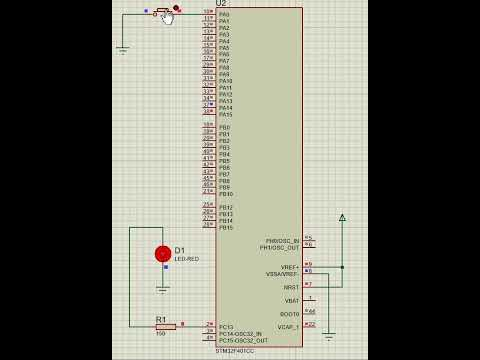

In [1]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('BxU0e9iXK0g', width=800, height=450)


### Algorithme d'anti-redonds logiciel : Lecture d'un bouton poussoir


À chaque appui sur le bouton poussoir connectee sur la broche PA0 la LED sur PC13 bascule son état. 

```c
#include "stm32f4xx.h"

// Définitions matérielles pour la Black Pill
#define BTN_PORT    GPIOA
#define BTN_PIN     0
#define LED_PORT    GPIOC
#define LED_PIN     13

// Drapeau (flag) partagé entre l'ISR et le main
// "volatile" est obligatoire pour indiquer au compilateur que cette variable change sous interruption
volatile uint8_t button_pressed_flag = 0;

// Fonction de délai rudimentaire (uniquement pour la boucle principale)
void delay_ms(uint32_t ms) {
    for (uint32_t i = 0; i < ms * 1600; i++) {
        __NOP();
    }
}

void GPIO_Init(void) {
    // 1. Activer l'horloge pour les ports A et C
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOAEN | RCC_AHB1ENR_GPIOCEN;

    // Configuration de PA0 (Bouton KEY) en entrée avec Pull-up
    BTN_PORT->MODER &= ~(3U << (BTN_PIN * 2));   // Mode Entrée (00)
    BTN_PORT->PUPDR &= ~(3U << (BTN_PIN * 2));   // Reset
    BTN_PORT->PUPDR |=  (1U << (BTN_PIN * 2));   // Active le Pull-up (01)

    // Configuration de PC13 (LED) en sortie push-pull
    LED_PORT->MODER &= ~(3U << (LED_PIN * 2));   // Reset
    LED_PORT->MODER |=  (1U << (LED_PIN * 2));   // Mode Sortie (01)
    
    // État initial de la LED : éteinte (Sortie à HIGH car Anode Commune)
    LED_PORT->BSRR = (1U << LED_PIN);
}

void EXTI_Init(void) {
    // 2. Activer l'horloge du bloc de configuration système SYSCFG
    RCC->APB2ENR |= RCC_APB2ENR_SYSCFGEN;

    // 3. Connecter la ligne EXTI0 au port A (Bits [3:0] de EXTICR[0] à 0000)
    // On nettoie les bits [3:0] de EXTICR[0] dédiés à la ligne EXTI0
    SYSCFG->EXTICR[0] &= ~SYSCFG_EXTICR1_EXTI0; // SYSCFG->EXTICR[0] &= ~(0xFU << 0);

    // 4. Sélectionner le front descendant (Falling Edge) : Appui relié au GND
    EXTI->FTSR |= (1 << 0);
    EXTI->RTSR &= ~(1 << 0); // Désactive le front montant pour cette ligne

    // 5. Démasquer (autoriser) l'interruption pour la ligne 0
    EXTI->IMR |= (1 << 0);

    // 6. Activer l'interruption EXTI0 dans le NVIC avec une priorité de 1
    NVIC_SetPriority(EXTI0_IRQn, 1);
    NVIC_EnableIRQ(EXTI0_IRQn);
}

// Routine d'interruption (ISR) dédiée à la ligne EXTI0
void EXTI0_IRQHandler(void) {
    // On vérifie que la ligne 0 est bien la cause de l'interruption
    if (EXTI->PR & (1 << 0)) {
        // 1. Acquitter immédiatement l'interruption en écrivant 1 dans le registre PR
        EXTI->PR = (1 << 0);

        // 2. Traitement ultra-court : on lève le drapeau et on quitte l'ISR
        // On ne fait PAS de basculement de LED ici pour éviter de subir les rebonds immédiats
        button_pressed_flag = 1;
    }
}

int main(void) {
    GPIO_Init();
    EXTI_Init();

    while (1) {
        // Le programme principal surveille le drapeau levé par l'interruption
        if (button_pressed_flag) {
            
            // ÉTAPE 1 : Anti-rebond temporel
            delay_ms(20); // On laisse les rebonds électriques se stabiliser
            
            // ÉTAPE 2 : Confirmation matérielle
            // On revérifie si le bouton est toujours physiquement enfoncé (état bas)
            if ((BTN_PORT->IDR & (1 << BTN_PIN)) == 0) {
                
                // L'appui est validé : on inverse la LED
                LED_PORT->ODR ^= (1 << LED_PIN);
                
                // ÉTAPE 3 : Anti-répétition (Attente du relâchement du bouton)
                while ((BTN_PORT->IDR & (1 << BTN_PIN)) == 0) {
                    __NOP(); // Ne fait rien tant que l'utilisateur maintient le bouton enfoncé
                }
            }
            
            // ÉTAPE 4 : Réinitialisation du drapeau pour le prochain appui
            button_pressed_flag = 0;
        }
        
        // Le reste de votre application principale s'exécute ici sans être bloqué par le bouton
    }
    
    return 0;
}


```

Dans ce genre de conditions, on ne peut plus utiliser la fonction bloquante de délais  (`__NOP()`), pour que notre programme ait une réactivité en temps réel. Nous allons utiliser un Timer matériel qui permet au processeur d'exécuter d'autres calculs pendant que le temps s'écoule et lui (Timer) fonctionne en arrière-plan du programme principal.


